[0.26466667 0.172      0.256     ]
[0.36       0.30133333 0.288     ]
[0.23466667 0.188      0.13733333]
[0.46466667 0.46133333 0.412     ]
[0.408      0.48133333 0.34733333]
[0.322      0.33266667 0.23866667]
[0.53866667 0.43333333 0.43066667]
[0.48466667 0.47533333 0.378     ]
[0.35733333 0.31666667 0.24      ]
[0.17066667 0.15533333 0.08866667]
[0.20733333 0.22533333 0.128     ]
[0.17933333 0.18933333 0.09666667]
[0.62266667 0.54466667 0.47733333]
[0.57466667 0.54133333 0.45      ]
[0.45066667 0.424      0.31866667]
[0.52       0.44133333 0.44533333]
[0.5        0.47866667 0.43066667]
[0.36666667 0.33866667 0.268     ]


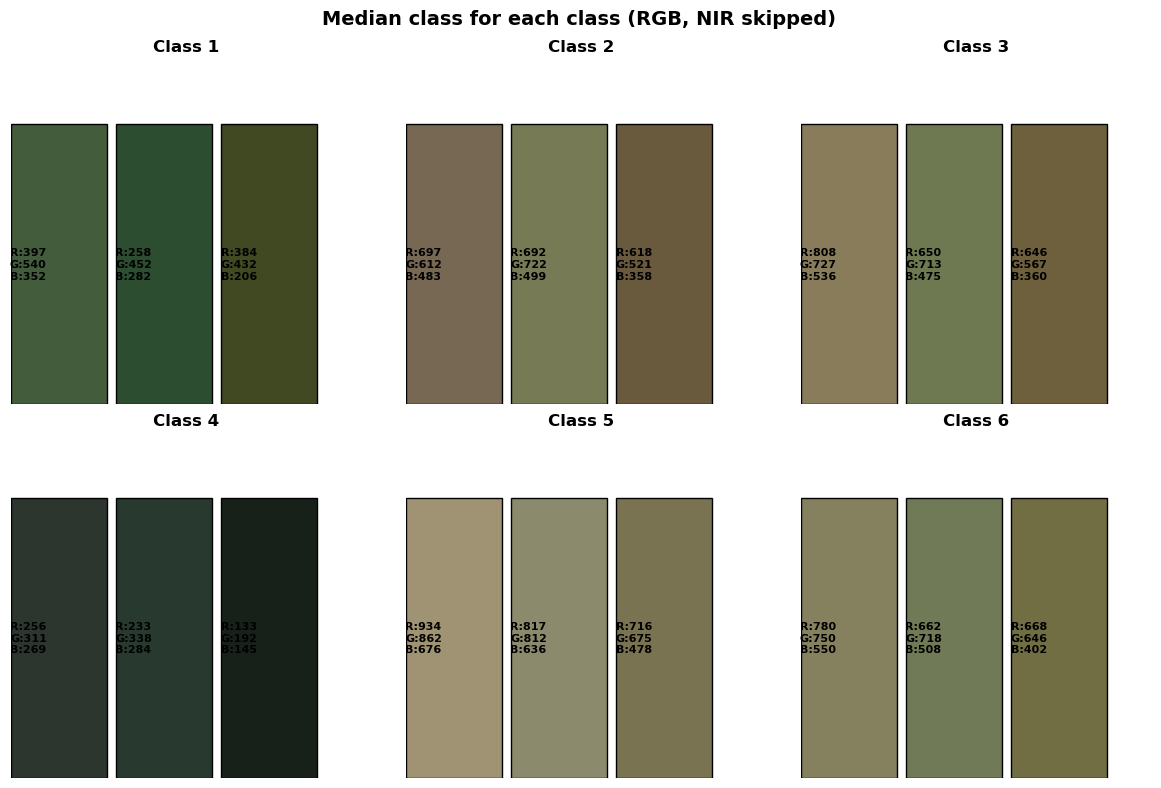

In [1]:
data = [
    [
        352,
        540,
        2374,
        397,
        282,
        452,
        3182,
        258,
        206,
        432,
        2484,
        384,
    ],
    [
        483,
        612,
        1378,
        697,
        499,
        722,
        2260,
        692,
        358,
        521,
        1408,
        618,
    ],
    [
        536,
        727,
        2019,
        808,
        475,
        713,
        2496,
        650,
        360,
        567,
        1849,
        646,
    ],
    [
        269,
        311,
        258,
        256,
        284,
        338,
        256,
        233,
        145,
        192,
        119,
        133,
    ],
    [
        676,
        862,
        1986,
        934,
        636,
        812,
        2250,
        817,
        478,
        675,
        1882,
        716,
    ],
    [
        550,
        750,
        1958,
        780,
        508,
        718,
        2516,
        662,
        402,
        646,
        2064,
        668,
    ],
]

from visualisation import *

draw_median_sign(data)

In [12]:
from utils import *
from prepare_ds import *
from train_ml import *
from create_map import *
from validation import *
from visualisation import *
from tqdm import tqdm
import matplotlib.pyplot as plt

downgrade_labels = False
force = True

if downgrade_labels:
    src = DEFAULT_PATH["labels"]
    out = DEFAULT_PATH["labels"] + "downgraded/"
    classes_matching = DEFAULT_PATH["labels"] + "classes_matching.csv"
    downgrade_classes(src, out, classes_matching, force=True)
    DEFAULT_PATH["labels"] = out

# you can use force=True for re-write all caches.
signs = parse_tifs_from(DEFAULT_PATH["images"], "sign", force=force)
signs = signs.query("type == 'sign'")
labels = parse_tifs_from(DEFAULT_PATH["labels"], "label", force=force)
labels = labels.query("type == 'label'")

# Prepare data for generate_dataset.
year = 2020
only_bands = ["r", "b", "g", "n"]
signs_paths = (
    signs.query(f"year == {year} and season == 'mon' and band in @only_bands")
    .sort_values("month")
    .sort_values("band")
)
signs_paths = signs_paths["path"].to_list()
labels_paths = labels.query(f"year == {year}")["path"].to_list()

In [13]:
signs_paths

In [39]:
homogen_layer = load_tif(
    "/Users/stephenhawking/Coding/ML/low2high_map/data/processing/resized/layers/homogeneous_layer.tif",
    only_first=True,
)
label = load_tif(
    "/Users/stephenhawking/Coding/ML/low2high_map/data/processing/cropped/labels/landcover23c_v571_2020.Samara.tif",
    only_first=True,
)

homogen_layer = homogen_layer["array"]
label = label["array"]

In [21]:
mask = homogen_layer > 0
l = label[mask].ravel()
b = homogen_layer[mask].ravel()

cl = np.unique(l)

plt.figure(figsize=(12, 8))
for c in cl:
    plt.hist(
        b[l == c], alpha=0.7, label=f"class {c}", bins=200, color=color_palette_plot[c]
    )
# plt.xlim(0, 1
plt.xlabel("Homogeneous")
plt.ylabel("Count")
plt.title("Homogeneous per Class")
plt.legend()
plt.show()

In [22]:
plt.clf()
plt.figure(figsize=(12, 8))
for c in cl:
    plt.hist(
        b[l == c],
        alpha=0.7,
        label=f"class {c}",
        bins=200,
        color=color_palette_plot[c],
        density=True,
    )
# plt.xlim(0, 1
plt.xlabel("Homogeneous")
plt.ylabel("Count")
plt.title("Normalized: Homogeneous per Class")
plt.legend()
plt.show()

In [36]:
sum_brightless = np.bincount(l, weights=b)
counts = np.bincount(l)
means = sum_brightless / counts

classes = np.arange(len(means))
colors = [color_palette_plot[c] for c in classes]

plt.figure(figsize=(4, 4))
plt.bar(classes, means, color=colors)
plt.xlabel("Class")
plt.ylabel("Mean of Homogeneous")
plt.title("Homogeneous")
plt.show()

In [23]:
# Check of the correlation with: NDVI, SAWI, NDMI

r = "/Users/stephenhawking/Coding/ML/low2high_map/data/processing/resized/images/reg_64_2020_06_90d_comp.r.tif"
r = load_tif(r, only_first=True)["array"].astype(np.float64)

n = "/Users/stephenhawking/Coding/ML/low2high_map/data/processing/resized/images/reg_64_2020_06_90d_comp.n.tif"
n = load_tif(n, only_first=True)["array"].astype(np.float64)

In [24]:
mask = r > 0
NDVI = (n - r) / (n + r + 1e-6)

# means = np.bincount(l, weights=NDVI)

plt.clf()
plt.figure(figsize=(12, 8))
for c in np.unique(label):
    plt.hist(
        NDVI[label == c],
        alpha=0.7,
        label=f"class {c}",
        bins=1000,
        color=color_palette_plot[c],
        density=True,
    )

# plt.xlim(0, 1)
print(NDVI.mean(), NDVI.size)

In [22]:
print("r: ", r.max(), r.min(), r.dtype)
print("n: ", n.max(), n.min(), n.dtype)
print("ndvi: ", NDVI.max(), NDVI.min(), NDVI.dtype)

In [42]:
mask = r > 0
L = 0.5
SAWI = (n - r) / (n + r + L + 1e-6) * (1 + L)

# means = np.bincount(l, weights=NDVI)

plt.clf()
plt.figure(figsize=(12, 8))
for c in np.unique(label):
    plt.hist(
        SAWI[label == c],
        alpha=0.7,
        label=f"class {c}",
        bins=50000,
        color=color_palette_plot[c],
        density=True,
    )

plt.xlim(0, 1)
print(SAWI.mean(), SAWI.size)
plt.bar(classes, means, color=colors)
plt.xlabel("Class")
plt.ylabel("SAWI")
plt.title("Check for classification: SAWI by classes")
plt.show()

In [ ]:
homogen_layer = load_tif(
    "/Users/stephenhawking/Coding/ML/low2high_map/src/../data/processing/resized/layers/px_of_std_landcover23c_v571_2020.Samara.tif",
    only_first=True,
)
label = load_tif(
    "/Users/stephenhawking/Coding/ML/low2high_map/data/processing/cropped/labels/landcover23c_v571_2020.Samara.tif",
    only_first=True,
)

homogen_layer = homogen_layer["array"]
label = label["array"]

mask = homogen_layer > 0
l = label[mask].ravel()
b = homogen_layer[mask].ravel()

cl = np.unique(l)

plt.figure(figsize=(12, 8))
for c in cl:
    plt.hist(
        b[l == c],
        alpha=0.7,
        label=f"class {c}",
        bins=100,
        color=color_palette_plot[c],
        density=True,
    )
plt.xlabel("std")
plt.ylabel("count px")
plt.title("Homogeneous by std")
# plt.xlim(0, 2)
plt.legend()
plt.show()

In [37]:
homogen_mask = mask.ravel()
homogen_percent = 0.2

classes = np.unique(l)
quantiles = []
for cl in classes:
    q = np.quantile(b[l == cl], homogen_percent)
    quantiles.append(q)
print(quantiles)
plt.bar(np.arange(len(quantiles)), quantiles)

In [ ]:
from scipy.ndimage import maximum_filter, minimum_filter, uniform_filter, sobel
from time import time
import numpy as np


def mask_cosine_dist_to_median_sign(signs, label, median_mode="simple", draw=True):
    x = np.moveaxis(signs, 0, -1)
    classes = np.unique(label[label > 0])
    print("x shape:", x.shape)

    r = 0.5

    print("Calculating secure area for selecting...")
    min_in_neighborhood = minimum_filter(label, size=(r))
    max_in_neighborhood = maximum_filter(label, size=(r))
    secure = min_in_neighborhood == max_in_neighborhood

    result_mask = np.ones_like(label, dtype=bool)
    result_mask[~secure] = 0

    print("Calculating median sign for each class...")
    for cl in classes[:2]:
        to_class = (label == cl) & result_mask
        print(f"Statistic for class: {cl}")

        if median_mode == "simple":
            y = np.median(x[to_class], axis=0)
            print(f"median of sign:\n{y}")

            norm_x = np.linalg.norm(x[result_mask], axis=1)
            norm_y = np.linalg.norm(y)
            scalar_x_y = x[result_mask].dot(y)
            print(
                f"shapes: x: {norm_x.shape}, y: {norm_y.shape}, scalar: {scalar_x_y.shape}"
            )

            cosine_dist = 1 - scalar_x_y / (norm_x * norm_y)
            to_class = (label == cl)[result_mask]
            dist_max = cosine_dist[to_class].max()
            print(f"max of dist to class == {cl}: {dist_max}")

            idx = np.where(result_mask)
            another = (label > cl)[result_mask] & (cosine_dist < dist_max)

            mask_remove = (
                idx[0][another],
                idx[1][another],
            )

            print(
                f"removed signatures for [label > {cl}]: {result_mask[mask_remove].size}"
            )
            result_mask[mask_remove] = 0
            print()

    # return result_mask


signs = np.random.randint(0, 100, size=(12, 100, 100))
label = np.random.randint(0, 6, size=(100, 100))
mask_cosine_dist_to_median_sign(signs, label)


x shape: (100, 100, 12)
Calculating secure area for selecting...
Calculating median sign for each class...
Statistic for class: 1
median of sign:
[51. 49. 49. 50. 50. 48. 50. 50. 52. 48. 48. 49.]
shapes: x: (10000,), y: (), scalar: (10000,)
max of dist to class == 1: 0.3092301893827316
removed signatures for [label > 1]: 6611

Statistic for class: 2
median of sign:
[ 8. 30.  9.  3. 90.  4. 11. 23.  0. 66. 82. 28.]
shapes: x: (3389,), y: (), scalar: (3389,)
max of dist to class == 2: 0.0
removed signatures for [label > 2]: 0



: 